## 1. Import Libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats.mstats import winsorize

# Sklearn preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Visualization settings
plt.style.use('ggplot')
sns.set_palette('husl')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')


## 2. Load Data


In [4]:
df=pd.read_csv('data_final_fix.csv')

## 2.1 Chuẩn hóa dữ liệu (Data Normalization)

### Lý do:
- `discount`: Đang ở dạng string "81%" → Chuyển sang float 0.81
- `num_reviews`: Đang ở dạng string "200,080" → Chuyển sang float 200080.0
- `num_students`: Đang ở dạng string "1,159,767" → Chuyển sang float 1159767.0
- `total_length`: Đang ở dạng string "42h 44m" → Chuyển sang minutes (số phút)


In [5]:
# Chuẩn hóa discount: "81%" -> 0.81
df['discount'] = df['discount'].str.replace('%', '').astype(float) / 100

# Chuẩn hóa num_reviews: "200,080" -> 200080.0
df['num_reviews'] = df['num_reviews'].str.replace(',', '').astype(float)

# Chuẩn hóa num_students: "1,159,767" -> 1159767.0
df['num_students'] = df['num_students'].str.replace(',', '').astype(float)

print('✓ Đã chuẩn hóa discount, num_reviews, num_students')


✓ Đã chuẩn hóa discount, num_reviews, num_students


In [6]:

import re
def convert_total_length_to_minutes(total_length):
    if pd.isna(total_length):
        return None
    duration_str = str(total_length)
    # Tìm số giờ
    hours = re.search(r'(\d+)h', duration_str)
    if hours:
        hours = int(hours.group(1))
    else:
        hours = 0
    # Tìm số phút
    minutes = re.search(r'(\d+)m', duration_str)
    if minutes:
        minutes = int(minutes.group(1))
    else:
        minutes = 0
    
    return hours * 60 + minutes
df['total_length_minutes'] = df['total_length'].apply(convert_total_length_to_minutes)
df.drop(columns=['total_length'], inplace=True)

In [7]:
# Kiểm tra kết quả sau chuẩn hóa
print('Kiểm tra data types sau chuẩn hóa:')
print(f'  discount: {df["discount"].dtype}')
print(f'  num_reviews: {df["num_reviews"].dtype}')
print(f'  num_students: {df["num_students"].dtype}')
print(f'  total_length_minutes: {df["total_length_minutes"].dtype}')

print('\nMẫu dữ liệu sau chuẩn hóa:')
print(df[['discount', 'num_reviews', 'num_students', 'total_length_minutes']].head())


Kiểm tra data types sau chuẩn hóa:
  discount: float64
  num_reviews: float64
  num_students: float64
  total_length_minutes: int64

Mẫu dữ liệu sau chuẩn hóa:
   discount  num_reviews  num_students  total_length_minutes
0      0.81     200080.0     1159767.0                  2564
1      0.78       2700.0      107821.0                  5950
2      0.82      28660.0      153392.0                  2640
3      0.82       7816.0      137461.0                   985
4      0.24      29071.0      115825.0                   267


In [8]:

print(f'Dataset shape: {df.shape}')
df.head()


Dataset shape: (10181, 16)


,timestamp,course_url,title,headline,is_bestseller,rating,num_reviews,num_students,instructor,language,price,discount,related_topics,sections,lectures,total_length_minutes
0,2025-10-06 19:36:49,https://www.udemy.com/course/machinelearning/,"Machine Learning A-Z: AI, Python & R + ChatGPT...",Learn to create Machine Learning Algorithms in...,Yes,4.5,200080.0,1159767.0,Kirill,English,369000.0,0.81,"Machine Learning, Data Science, Development",46.0,386.0,2564
1,2025-10-06 19:37:05,https://www.udemy.com/course/complete-machine-...,"Complete Data Science,Machine Learning,DL,NLP ...","Master the theory, practice,and math behind Da...",Yes,4.5,2700.0,107821.0,Krish,English,349000.0,0.78,"Data Science, Other IT & Software, IT & Software",63.0,429.0,5950
2,2025-10-06 19:37:19,https://www.udemy.com/course/complete-machine-...,"Complete A.I. & Machine Learning, Data Science...","Learn Data Science, Data Analysis, Machine Lea...",No,4.6,28660.0,153392.0,Andrei,English,339000.0,0.82,"Data Science, Development",21.0,384.0,2640
3,2025-10-06 19:38:12,https://www.udemy.com/course/machine-learning-...,Mathematical Foundations of Machine Learning,Essential Linear Algebra and Calculus Hands-On...,Yes,4.6,7816.0,137461.0,Dr,English,389000.0,0.82,"Math, Data Science, Development",11.0,114.0,985
4,2025-10-06 19:38:54,https://www.udemy.com/course/machine-learning-...,Machine Learning for Absolute Beginners - Level 1,Learn the Fundamental Concepts of Artificial I...,No,4.5,29071.0,115825.0,Idan,English,339000.0,0.24,"Machine Learning, Data Science, Development",8.0,59.0,267


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10181 entries, 0 to 10180
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             10181 non-null  object 
 1   course_url            10181 non-null  object 
 2   title                 10181 non-null  object 
 3   headline              10178 non-null  object 
 4   is_bestseller         10181 non-null  object 
 5   rating                10181 non-null  float64
 6   num_reviews           10181 non-null  float64
 7   num_students          10181 non-null  float64
 8   instructor            10181 non-null  object 
 9   language              10181 non-null  object 
 10  price                 10181 non-null  float64
 11  discount              9831 non-null   float64
 12  related_topics        10181 non-null  object 
 13  sections              10181 non-null  float64
 14  lectures              10181 non-null  float64
 15  total_length_minute

## 3. Xử lý Missing Values & Duplicates







In [10]:
duplicates = df.duplicated()
dup_count=duplicates.sum()

In [11]:
missing_data=pd.DataFrame(
    {
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percent' : ((df.isnull().sum()/len(df))*100).round(2),
        'Data_Type': df.dtypes
    }
)

missing_data=missing_data[missing_data['Missing_Count']>0].sort_values(by='Missing_Percent', ascending=False)

if len(missing_data)>0:
    print("\n Missing Value Summary:")
    print(missing_data.to_string(index=False))


 Missing Value Summary:
  Column  Missing_Count  Missing_Percent Data_Type
discount            350             3.44   float64
headline              3             0.03    object


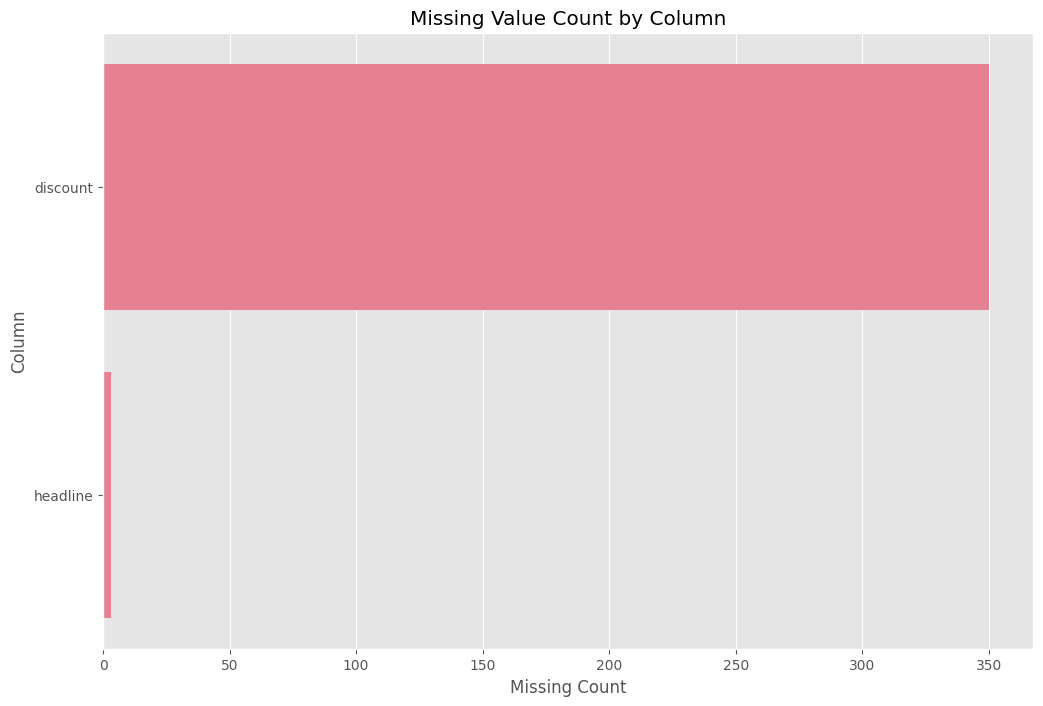

In [12]:
def plot_missing_values(missing_data):
    if len(missing_data)>0:
       figsize=(12,8)
       plt.figure(figsize=figsize)
       sns.barplot(x='Missing_Count', y='Column', data=missing_data, orient='h')
       plt.title('Missing Value Count by Column')
       plt.xlabel('Missing Count')
       plt.ylabel('Column')
       plt.show()

plot_missing_values(missing_data)

In [13]:
dup_count = df.duplicated().sum()
print(f'Found {dup_count} duplicate rows ({(dup_count/len(df)*100):.2f}%)')



Found 2 duplicate rows (0.02%)


####  Nhận xét:
- **discount**: thiếu 3.44% - có thể là khóa không giảm giá
- **headline**: thiếu 0.03% - chỉ 3 dòng, không đáng kể
- **duplicate**: phát hiện 2 dòng trùng lặp
#### Hướng xử lý:
- Điền discount = 0 (giả định không có giảm giá)
- Xóa 3 dòng thiếu headline
- Xóa 2 dòng trùng lặp
- Kiểm tra không còn missing values


In [14]:
if dup_count > 0:
    df = df.drop_duplicates(keep='first')
    print(f'Removed {dup_count} duplicates. New shape: {df.shape}')

Removed 2 duplicates. New shape: (10179, 16)


In [15]:
# Task 1: Điền discount = 0 (giả định không có giảm giá)
df['discount'] = df['discount'].fillna(0)

# Task 2: Xóa 3 dòng thiếu headline
df = df.dropna(subset=['headline'])

# Task 3: Kiểm tra không còn missing values
missing_check = df.isnull().sum()
missing_total = missing_check.sum()

if missing_total == 0:
    print(f'Da xu ly xong. Kich thuoc du lieu: {df.shape}')
    print('Khong con missing values.')
else:
    print('Con missing values:')
    print(missing_check[missing_check > 0])


Da xu ly xong. Kich thuoc du lieu: (10176, 16)
Khong con missing values.


## 4. Xử lý Outlier 

####  Nhận xét:
- **rating**: 7.26% outliers - có rating = 0 (lỗi)
- **num_reviews, num_students**: 15-16% outliers - nhưng là dữ liệu thật (khóa hot)
- **price**: 6.90% outliers - giá quá cao, cần kiểm tra
- **sections, lectures, total_length**: outliers hợp lý (khóa comprehensive)

####  Hướng xử lý:
- **Xóa**: rating = 0 (lỗi rõ ràng)
- **Giữ nguyên**: num_reviews, num_students, sections, lectures (dữ liệu thật)
- **Transform**: Dùng log transformation cho num_reviews, num_students để giảm skewness
- **Capping**: cap price ở 95th percentile nếu cần
- **Scaling**: Dùng RobustScaler (chịu outliers tốt) thay vì StandardScaler

In [16]:
# Task 1: Xóa rating = 0 (lỗi rõ ràng)
before_drop = len(df)
df = df[df['rating'] > 0]
after_drop = len(df)
print(f'Da xoa {before_drop - after_drop} dong co rating = 0. Kich thuoc moi: {df.shape}')

# Task 2: Log transformation cho num_reviews, num_students để giảm skewness
# Thêm 1 để tránh log(0)
df['log_num_reviews'] = np.log1p(df['num_reviews'])
df['log_num_students'] = np.log1p(df['num_students'])
print('Da tao log_num_reviews va log_num_students')

# Task 3: Capping price ở 95th percentile
price_95th = df['price'].quantile(0.95)
df['price_capped'] = df['price'].clip(upper=price_95th)
print(f'Da cap price tai 95th percentile: {price_95th:.2f}')

# Task 4: Import RobustScaler (sẽ dùng sau ở bước scaling)
from sklearn.preprocessing import RobustScaler
print('Da import RobustScaler de su dung sau nay')

Da xoa 416 dong co rating = 0. Kich thuoc moi: (9760, 16)
Da tao log_num_reviews va log_num_students
Da cap price tai 95th percentile: 399000.00
Da import RobustScaler de su dung sau nay


## 5. Xử lí Skewed Distribution

#### Nhận xét:
- **rating**: Lệch trái mạnh (skewness = -3.71) - hầu hết khóa rating cao
- **num_reviews, num_students**: Lệch phải CỰC MẠNH (skewness >15) - cần transform
- **price**: Lệch phải (skewness = 11.30) - cần xử lý
- **discount**: Phân phối bimodal (2 đỉnh) - phản ánh 2 chiến lược giảm giá

#### Hướng xử lý:
- **Log transform**: num_reviews, num_students, price (skewness >10)
- **Square root transform**: sections, lectures (skewness 2-4)
- **Rating**: Giữ nguyên 
- **Discount**: Giữ nguyên
- Sau transform, verify skewness giảm xuống (-1 đến 1)


In [17]:
# Task 1: Log transform cho num_reviews, num_students, price (skewness >10)
# Đã tạo log_num_reviews, log_num_students ở bước trước
# Tạo thêm log transform cho price và total_length_minutes
df['log_price'] = np.log1p(df['price'])
df['log_total_length_minutes'] = np.log1p(df['total_length_minutes'])

# Task 2: Square root transform cho sections, lectures
df['sqrt_sections'] = np.sqrt(df['sections'])
df['sqrt_lectures'] = np.sqrt(df['lectures'])

# Task 3 & 4: Rating và Discount giữ nguyên (không cần transform)

print('Da hoan thanh cac transform:')


Da hoan thanh cac transform:


In [18]:
# Tính skewness trước và sau transform
original_cols = ['num_reviews', 'num_students', 'price', 'total_length_minutes', 'sections', 'lectures', 'rating', 'discount']
transformed_cols = ['log_num_reviews', 'log_num_students', 'log_price', 'log_total_length_minutes', 'sqrt_sections', 'sqrt_lectures', 'rating', 'discount']

skew_before = df[original_cols].skew()
skew_after = df[transformed_cols].skew()

skew_comparison = pd.DataFrame({
    'Column': original_cols,
    'Skewness_Before': skew_before.values,
    'Transformed_Column': transformed_cols,
    'Skewness_After': skew_after.values,
    'Improvement': skew_before.values - skew_after.values
})

print('So sanh Skewness truoc va sau transform:')
print('=' * 100)
print(skew_comparison.to_string(index=False))
print('=' * 100)


So sanh Skewness truoc va sau transform:
              Column  Skewness_Before       Transformed_Column  Skewness_After  Improvement
         num_reviews        22.164756          log_num_reviews        0.344595    21.820161
        num_students        15.032751         log_num_students       -0.186845    15.219596
               price        12.107236                log_price        6.106543     6.000693
total_length_minutes         4.065194 log_total_length_minutes       -0.043024     4.108218
            sections         3.715504            sqrt_sections        1.454487     2.261017
            lectures         2.892187            sqrt_lectures        1.311872     1.580315
              rating        -1.635771                   rating       -1.635771     0.000000
            discount         0.366471                 discount        0.366471     0.000000


## 6. Feature Engineering

### Mục tiêu:
- Tạo các feature mới giúp mô hình học được mối quan hệ phi tuyến và tương tác giữa các biến.
- Giảm multicollinearity đã phát hiện trong EDA.
- Giữ dữ liệu linh hoạt, không phụ thuộc vào mô hình cụ thể.

### Lý do thực hiện (theo EDA):
- num_students và num_reviews có correlation ~0.9 → multicollinearity nghiêm trọng → nên gộp hoặc giữ 1 biến.
- price có correlation gần 0 với target → không còn giá trị dự đoán độc lập.
- discount là feature mạnh nhất (corr ≈ 0.36), ảnh hưởng trực tiếp đến bestseller → cần giữ và mở rộng.
- rating có correlation thấp, nhưng có thể có hiệu ứng tương tác với độ phổ biến (rating × students).
- lectures và total_length có correlation cao → nên chọn 1 biến đại diện, đồng thời tạo feature tổng hợp theo hiệu suất học (price_per_hour).



In [19]:
# 1. Tao feature moi phan anh insight tu EDA
df['effective_price'] = df['price'] * (1 - df['discount'])
df['popularity_score'] = (df['num_students'] + df['num_reviews']) / 2
df['rating_x_students'] = df['rating'] * df['num_students']
df['price_per_hour'] = df['price'] / (df['total_length_minutes'] / 60 + 1e-3)

# 2. Tao nhom discount (Low/Medium/High) de kiem tra chien luoc giam gia khac nhau
df['discount_category'] = pd.cut(df['discount'],
                                 bins=[0, 0.3, 0.6, 1.0],
                                 labels=['Low', 'Medium', 'High'])

# 3. Loai bo cac feature trung hoac it y nghia
cols_to_drop = ['num_reviews', 'sections']
df = df.drop(columns=cols_to_drop, errors='ignore')

print("Hoan thanh Feature Engineering: tao feature moi va loai bo bien trung lap.")
print(f'Kich thuoc du lieu: {df.shape}')
df.head()


Hoan thanh Feature Engineering: tao feature moi va loai bo bien trung lap.
Kich thuoc du lieu: (9760, 26)


,timestamp,course_url,title,headline,is_bestseller,rating,num_students,instructor,language,price,discount,related_topics,lectures,total_length_minutes,log_num_reviews,log_num_students,price_capped,log_price,log_total_length_minutes,sqrt_sections,sqrt_lectures,effective_price,popularity_score,rating_x_students,price_per_hour,discount_category
0,2025-10-06 19:36:49,https://www.udemy.com/course/machinelearning/,"Machine Learning A-Z: AI, Python & R + ChatGPT...",Learn to create Machine Learning Algorithms in...,Yes,4.5,1159767.0,Kirill,English,369000.0,0.81,"Machine Learning, Data Science, Development",386.0,2564,12.206478,13.963731,369000.0,12.818555,7.849714,6.782330,19.646883,70110.0,679923.5,5218951.5,8634.743337,High
1,2025-10-06 19:37:05,https://www.udemy.com/course/complete-machine-...,"Complete Data Science,Machine Learning,DL,NLP ...","Master the theory, practice,and math behind Da...",Yes,4.5,107821.0,Krish,English,349000.0,0.78,"Data Science, Other IT & Software, IT & Software",429.0,5950,7.901377,11.588237,349000.0,12.762830,8.691315,7.937254,20.712315,76780.0,55260.5,485194.5,3519.292242,High
2,2025-10-06 19:37:19,https://www.udemy.com/course/complete-machine-...,"Complete A.I. & Machine Learning, Data Science...","Learn Data Science, Data Analysis, Machine Lea...",No,4.6,153392.0,Andrei,English,339000.0,0.82,"Data Science, Development",384.0,2640,10.263293,11.940759,339000.0,12.733758,7.878913,4.582576,19.595918,61020.0,91026.0,705603.2,7704.370355,High
3,2025-10-06 19:38:12,https://www.udemy.com/course/machine-learning-...,Mathematical Foundations of Machine Learning,Essential Linear Algebra and Calculus Hands-On...,Yes,4.6,137461.0,Dr,English,389000.0,0.82,"Math, Data Science, Development",114.0,985,8.964056,11.831103,389000.0,12.871337,6.893656,3.316625,10.677078,70020.0,72638.5,632320.6,23693.988183,High
4,2025-10-06 19:38:54,https://www.udemy.com/course/machine-learning-...,Machine Learning for Absolute Beginners - Level 1,Learn the Fundamental Concepts of Artificial I...,No,4.5,115825.0,Idan,English,339000.0,0.24,"Machine Learning, Data Science, Development",59.0,267,10.277531,11.659844,339000.0,12.733758,5.590987,2.828427,7.681146,257640.0,72448.0,521212.5,76162.660076,Low


In [20]:
# Hien thi thong tin cac feature moi da tao
new_features = ['effective_price', 'popularity_score', 'rating_x_students', 'price_per_hour', 'discount_category']

print('\nCac feature moi da tao:')
for feat in new_features:
    if feat in df.columns:
        print(f'  - {feat}')

print('\nThong ke mo ta cac feature moi (so):')
numeric_new_features = ['effective_price', 'popularity_score', 'rating_x_students', 'price_per_hour']
print(df[numeric_new_features].describe().T[['mean', 'std', 'min', 'max']])

print('\nPhan phoi discount_category:')
print(df['discount_category'].value_counts().sort_index())

print(f'\nCac cot da xoa: num_reviews, sections')
print(f'Tong so cot hien tai: {len(df.columns)}')



Cac feature moi da tao:
  - effective_price
  - popularity_score
  - rating_x_students
  - price_per_hour
  - discount_category

Thong ke mo ta cac feature moi (so):
                            mean            std           min           max
effective_price    193458.196014  162697.147020  44640.000000  2.499000e+06
popularity_score     9035.643904   39840.724511      1.000000  1.321564e+06
rating_x_students   72458.186332  311007.905936      3.500000  9.637051e+06
price_per_hour      73061.111659   98838.871117   1231.888777  3.482118e+06

Phan phoi discount_category:
discount_category
Low       5986
Medium     232
High      3234
Name: count, dtype: int64

Cac cot da xoa: num_reviews, sections
Tong so cot hien tai: 26


## 7. Xử lý Categorical Features

### Mục tiêu:
- Biến các feature dạng category thành dạng numeric để sẵn sàng cho mọi mô hình.
- Dữ liệu sau bước này có thể dùng cho cả tree-based models và linear models.

### Lý do thực hiện (theo EDA):
- Một số feature như category, level, subject có thể ảnh hưởng đến bestseller, nhưng chưa được encode.
- Giữ cả 2 phiên bản encode để linh hoạt thử nghiệm:
  + LabelEncoder → phù hợp tree-based models (Random Forest, XGBoost).
  + One-Hot Encoding → phù hợp mô hình tuyến tính (Logistic, Linear, SVM).



In [21]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(cat_cols))

# 1. Label Encoding (cho tree-based)
df_label_encoded = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col].astype(str))

# 2. One-Hot Encoding (cho linear-based)
df_onehot_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Hoan tat encoding. Sinh ra hai phien ban du lieu:")
print("- df_label_encoded: cho tree-based models")
print("- df_onehot_encoded: cho linear / logistic models")


Categorical columns: ['timestamp', 'course_url', 'title', 'headline', 'is_bestseller', 'instructor', 'language', 'related_topics', 'discount_category']
Hoan tat encoding. Sinh ra hai phien ban du lieu:
- df_label_encoded: cho tree-based models
- df_onehot_encoded: cho linear / logistic models


In [22]:
# Hien thi ket qua encoding
print('\nThong tin du lieu sau encoding:')
print('=' * 80)

print(f'\n1. Label Encoded (tree-based):')
print(f'   - Kich thuoc: {df_label_encoded.shape}')
print(f'   - So cot: {len(df_label_encoded.columns)}')
print(f'   - Cac cot categorical da encode: {list(cat_cols)}')

print(f'\n2. One-Hot Encoded (linear-based):')
print(f'   - Kich thuoc: {df_onehot_encoded.shape}')
print(f'   - So cot: {len(df_onehot_encoded.columns)}')
print(f'   - So cot tang them: {len(df_onehot_encoded.columns) - len(df_label_encoded.columns)}')

print('\n' + '=' * 80)
print('Mau du lieu Label Encoded (5 dong dau):')
print(df_label_encoded.head())



Thong tin du lieu sau encoding:

1. Label Encoded (tree-based):
   - Kich thuoc: (9760, 26)
   - So cot: 26
   - Cac cot categorical da encode: ['timestamp', 'course_url', 'title', 'headline', 'is_bestseller', 'instructor', 'language', 'related_topics', 'discount_category']

2. One-Hot Encoded (linear-based):
   - Kich thuoc: (9760, 34451)
   - So cot: 34451
   - So cot tang them: 34425

Mau du lieu Label Encoded (5 dong dau):
   timestamp  course_url  title  headline  is_bestseller  rating  \
0        589        4267   4103      4421              1     4.5   
1        590        1444   1416      5303              1     4.5   
2        591        1438   1380      3051              0     4.6   
3        592        4108   4721      1986              1     4.6   
4        593        4120   4186      4130              0     4.5   

   num_students  instructor  language     price  discount  related_topics  \
0     1159767.0        1018         0  369000.0      0.81            1329   
1    

## 8. Feature Selection

### Mục tiêu:
- Loại bỏ các feature dư thừa, ít thông tin hoặc gây đa cộng tuyến.
- Giữ lại các feature có ý nghĩa thống kê và khả năng dự đoán cao.

### Lý do thực hiện (theo EDA):
- num_students ↔ num_reviews: correlation cao ~0.9 → loại 1 biến.
- sections ↔ lectures ↔ total_length: correlation cao → giữ 1–2 biến tiêu biểu.
- rating có correlation thấp nhưng vẫn giữ vì có thể xuất hiện tương tác (nonlinear hoặc interaction effects).
- price không có ý nghĩa (corr ~ 0.006) → loại bỏ.
- discount là feature quan trọng nhất → giữ bắt buộc.



In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Tach X va y (gia su target la 'is_bestseller')
X = df_label_encoded.drop(columns=['is_bestseller'])
y = df_label_encoded['is_bestseller']

# Kiem tra multicollinearity qua VIF
numeric_cols = X.select_dtypes(include=np.number).columns
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(X[numeric_cols].values, i) for i in range(len(numeric_cols))]

print("Variance Inflation Factors (VIF):")
print('=' * 80)
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))
print('=' * 80)

Variance Inflation Factors (VIF):
                 feature        VIF
       rating_x_students 923.770694
                   price 878.952896
               log_price 801.419129
            num_students 727.149799
         effective_price 454.293944
log_total_length_minutes 406.163595
            price_capped 359.300754
                  rating 175.976775
                discount 167.390685
           sqrt_lectures 145.556336
        popularity_score 137.789018
                lectures  41.185756
        log_num_students  31.980527
         log_num_reviews  18.532287
           sqrt_sections  15.059860
    total_length_minutes   8.857997
              course_url   8.602312
       discount_category   8.381494
                   title   8.129506
          related_topics   5.514622
          price_per_hour   5.412329
                headline   4.160474
              instructor   4.127882
               timestamp   3.430549
                language        NaN


In [24]:
# Tinh correlation voi target
corr_with_target = X[numeric_cols].corrwith(y).abs().sort_values(ascending=False)

print("\nCorrelation voi target (is_bestseller):")
print('=' * 80)
for feat, corr_val in corr_with_target.items():
    print(f"{feat:30s}: {corr_val:.4f}")
print('=' * 80)

# Goi y loai bo features
print("\nGoi y loai bo features:")
print("- Features co VIF > 5: ", list(vif_data[vif_data['VIF'] > 5]['feature']))
print("- Features co |correlation| < 0.05: ", list(corr_with_target[corr_with_target < 0.05].index))

# Ket hop ca 2 tieu chi
features_to_drop = set(vif_data[vif_data['VIF'] > 5]['feature']).union(
    set(corr_with_target[corr_with_target < 0.05].index)
)
print(f"\nTong cong {len(features_to_drop)} features nen loai bo: {features_to_drop}")



Correlation voi target (is_bestseller):
discount                      : 0.3545
rating                        : 0.3497
discount_category             : 0.2535
log_total_length_minutes      : 0.1843
effective_price               : 0.1782
sqrt_sections                 : 0.1618
price_per_hour                : 0.1472
sqrt_lectures                 : 0.1438
total_length_minutes          : 0.1232
log_num_reviews               : 0.1077
lectures                      : 0.1056
rating_x_students             : 0.0966
popularity_score              : 0.0965
num_students                  : 0.0926
title                         : 0.0730
timestamp                     : 0.0688
instructor                    : 0.0640
headline                      : 0.0598
related_topics                : 0.0479
course_url                    : 0.0440
price_capped                  : 0.0420
log_num_students              : 0.0249
log_price                     : 0.0198
price                         : 0.0114
language               

In [25]:
X.describe()

,timestamp,course_url,title,headline,rating,num_students,instructor,language,price,discount,related_topics,lectures,total_length_minutes,log_num_reviews,log_num_students,price_capped,log_price,log_total_length_minutes,sqrt_sections,sqrt_lectures,effective_price,popularity_score,rating_x_students,price_per_hour,discount_category
count,9760.000000,9760.000000,9760.000000,9760.000000,9760.000000,9.760000e+03,9760.000000,9760.0,9.760000e+03,9760.000000,9760.000000,9760.000000,9760.000000,9760.000000,9760.000000,9760.000000,9760.000000,9760.000000,9760.000000,9760.000000,9.760000e+03,9.760000e+03,9.760000e+03,9.760000e+03,9760.000000
mean,3934.846721,3486.921414,3444.451639,3479.902459,4.450666,1.618505e+04,1085.606865,0.0,3.201875e+05,0.407759,1206.281660,96.646107,726.590779,4.762330,7.328751,308274.590164,12.648779,6.078233,3.380036,8.837445,1.934582e+05,9.035644e+03,7.245819e+04,7.306111e+04,0.755533
std,2605.872034,2061.412398,2060.042623,1988.583519,0.361481,6.839562e+04,621.749622,0.0,1.345427e+05,0.252948,628.535683,104.810756,905.019543,2.292761,2.458977,33315.392392,0.186373,1.024103,1.430907,4.306689,1.626971e+05,3.984072e+04,3.110079e+05,9.883887e+04,0.649332
min,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000e+00,0.000000,0.0,2.790000e+05,0.000000,0.000000,1.000000,28.000000,0.693147,0.693147,279000.000000,12.538971,3.367296,1.000000,1.000000,4.464000e+04,1.000000e+00,3.500000e+00,1.231889e+03,0.000000
25%,1548.750000,1796.750000,1715.750000,1723.750000,4.300000,2.500000e+02,531.000000,0.0,2.790000e+05,0.250000,703.000000,33.000000,223.000000,3.044522,5.525453,279000.000000,12.538971,5.411646,2.449490,5.744563,9.486000e+04,1.585000e+02,1.113900e+03,2.097143e+04,0.000000
50%,3916.500000,3428.500000,3328.500000,3499.500000,4.500000,1.731000e+03,1081.000000,0.0,2.990000e+05,0.300000,1246.000000,64.000000,442.000000,4.465908,7.457032,299000.000000,12.608202,6.093570,3.162278,8.000000,1.953000e+05,1.005500e+03,7.550400e+03,4.175326e+04,1.000000
75%,6219.250000,5223.000000,5221.250000,5109.250000,4.700000,9.032000e+03,1622.000000,0.0,3.190000e+05,0.700000,1724.250000,118.000000,900.250000,6.326149,9.108640,319000.000000,12.672950,6.803783,3.872983,10.862780,2.242500e+05,4.986875e+03,3.990645e+04,8.409525e+04,1.000000
max,8523.000000,7152.000000,7124.000000,7072.000000,5.000000,2.095011e+06,2180.000000,0.0,2.499000e+06,0.840000,2380.000000,800.000000,15050.000000,13.214248,14.555070,399000.000000,14.731402,9.619200,13.266499,28.284271,2.499000e+06,1.321564e+06,9.637051e+06,3.482118e+06,3.000000


In [26]:
# Loai bo features du thua (optional - co the bo qua neu muon giu tat ca features)
# Dua tren phan tich VIF va correlation

# Loai bo cac features khong can thiet (timestamp, course_url, title, headline, instructor, language, related_topics)
features_to_remove = ['timestamp', 'course_url', 'title', 'headline', 'instructor', 'language', 'related_topics','num_students'
,'price_capped','num_reviews', 'num_students', 'price', 'total_length_minutes', 'sections', 'lectures', 'rating_x_students']

# Loc ra cac features co trong X    
features_to_remove_exist = [f for f in features_to_remove if f in X.columns]

if features_to_remove_exist:
    X_selected = X.drop(columns=features_to_remove_exist)
    print(f"Da loai bo {len(features_to_remove_exist)} features khong can thiet: {features_to_remove_exist}")
else:
    X_selected = X.copy()
    print("Khong co features nao duoc loai bo")

print(f"\nKich thuoc X truoc khi loai bo: {X.shape}")
print(f"Kich thuoc X sau khi loai bo: {X_selected.shape}")
print(f"So features con lai: {len(X_selected.columns)}")
print(f"\nDanh sach features con lai:\n{list(X_selected.columns)}")


Da loai bo 14 features khong can thiet: ['timestamp', 'course_url', 'title', 'headline', 'instructor', 'language', 'related_topics', 'num_students', 'price_capped', 'num_students', 'price', 'total_length_minutes', 'lectures', 'rating_x_students']

Kich thuoc X truoc khi loai bo: (9760, 25)
Kich thuoc X sau khi loai bo: (9760, 12)
So features con lai: 12

Danh sach features con lai:
['rating', 'discount', 'log_num_reviews', 'log_num_students', 'log_price', 'log_total_length_minutes', 'sqrt_sections', 'sqrt_lectures', 'effective_price', 'popularity_score', 'price_per_hour', 'discount_category']


In [27]:
# Cap nhat lai df_label_encoded va df_onehot_encoded sau khi loai bo features
df_label_encoded_selected = df_label_encoded.drop(columns=features_to_remove_exist, errors='ignore')
df_onehot_encoded_selected = df_onehot_encoded.drop(columns=features_to_remove_exist, errors='ignore')

print("Cap nhat lai du lieu sau Feature Selection:")
print(f"- df_label_encoded: {df_label_encoded.shape} -> {df_label_encoded_selected.shape}")
print(f"- df_onehot_encoded: {df_onehot_encoded.shape} -> {df_onehot_encoded_selected.shape}")

# Su dung df_label_encoded_selected cho cac buoc tiep theo
df_final = df_label_encoded_selected.copy()
print(f"\nDu lieu final de preprocessing tiep: {df_final.shape}")


Cap nhat lai du lieu sau Feature Selection:
- df_label_encoded: (9760, 26) -> (9760, 13)
- df_onehot_encoded: (9760, 34451) -> (9760, 34445)

Du lieu final de preprocessing tiep: (9760, 13)


In [28]:
output_path = "data_final_preprocessed.csv"
df_final.to_csv(output_path, index=False, encoding='utf-8-sig')

## 9. Scaling & Normalization

### Mục tiêu:
- Chuẩn hóa tất cả features về cùng thang đo để mô hình học tốt hơn.
- Sử dụng RobustScaler vì dữ liệu có outliers (đã phân tích ở bước 4).

### Lý do thực hiện (theo EDA):
- Các features có thang đo khác nhau: price (279k-2.5M), rating (0-5), discount (0-1)
- Log-transformed features đã giảm skewness nhưng vẫn cần chuẩn hóa về cùng thang đo
- RobustScaler chịu outliers tốt hơn StandardScaler (sử dụng median và IQR thay vì mean và std)
- Chỉ fit scaler trên training set, sau đó transform cả train và test để tránh data leakage


In [29]:
# Chuan bi du lieu cho scaling
# Tach X va y tu df_final (da loai bo cac features khong can thiet)
X = df_final.drop(columns=['is_bestseller'])
y = df_final['is_bestseller']

print(f'Chuan bi du lieu cho Scaling:')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

print(f'\nTarget distribution:')
print(f'  No (0): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)')
print(f'  Yes (1): {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)')

print(f'\nCac features se duoc scale:')
print(list(X.columns))


Chuan bi du lieu cho Scaling:
X shape: (9760, 12)
y shape: (9760,)

Target distribution:
  No (0): 7509 (76.9%)
  Yes (1): 2251 (23.1%)

Cac features se duoc scale:
['rating', 'discount', 'log_num_reviews', 'log_num_students', 'log_price', 'log_total_length_minutes', 'sqrt_sections', 'sqrt_lectures', 'effective_price', 'popularity_score', 'price_per_hour', 'discount_category']


### Chú ý về thứ tự Scaling:
- Cách đúng: Train-Test Split TRƯỚC, sau đó Scale RIÊNG BIỆT
- Fit scaler chỉ trên train set → Transform cả train và test
- Tránh data leakage (test set không được ảnh hưởng đến việc tính toán scaling parameters)


## 10. Train-Test Split (Stratified)

### Lý do từ EDA:
- Class imbalance nghiêm trọng: No (82.5%) vs Yes (17.5%)
- Stratified split đảm bảo tỷ lệ class giống nhau ở train và test set
- Test size = 20%, random_state = 42 để reproducibility


In [30]:
# Thuc hien Train-Test Split TRUOC khi scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train-Test Split (chua scale):')
print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

print(f'\nTrain class distribution: No={(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%), Yes={(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)')
print(f'Test class distribution: No={(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%), Yes={(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)')


Train-Test Split (chua scale):
Train set: (7808, 12)
Test set: (1952, 12)

Train class distribution: No=6007 (76.9%), Yes=1801 (23.1%)
Test class distribution: No=1502 (76.9%), Yes=450 (23.1%)


## 11. Apply Scaling với RobustScaler

### Lý do chọn RobustScaler:
- Sử dụng median và IQR thay vì mean và std → chịu outliers tốt hơn
- Phù hợp với dữ liệu đã được phân tích có nhiều outliers ở bước 4
- Fit scaler chỉ trên train set để tránh data leakage


In [31]:
# Khoi tao RobustScaler
scaler = RobustScaler()

# Fit scaler chi tren train set
scaler.fit(X_train)

# Transform ca train va test set
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Chuyen ve DataFrame de giu ten cot
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('Da hoan thanh Scaling voi RobustScaler')
print('=' * 80)
print(f'\nKich thuoc du lieu:')
print(f'  - X_train_scaled: {X_train_scaled.shape}')
print(f'  - X_test_scaled: {X_test_scaled.shape}')

print(f'\nThong ke truoc khi scale (train set - 5 features dau):')
print(X_train.describe().T[['mean', 'std', 'min', 'max']].head(5))

print(f'\nThong ke sau khi scale (train set - 5 features dau):')
print(X_train_scaled.describe().T[['mean', 'std', 'min', 'max']].head(5))

print('\n' + '=' * 80)
print('Luu y: RobustScaler su dung median va IQR nen mean khong bang 0')


Da hoan thanh Scaling voi RobustScaler

Kich thuoc du lieu:
  - X_train_scaled: (7808, 12)
  - X_test_scaled: (1952, 12)

Thong ke truoc khi scale (train set - 5 features dau):
                       mean       std        min        max
rating             4.448258  0.360382   1.000000   5.000000
discount           0.407145  0.253232   0.000000   0.840000
log_num_reviews    4.787871  2.304172   0.693147  12.885316
log_num_students   7.343752  2.461754   0.693147  14.481554
log_price         12.647336  0.177678  12.538971  14.731402

Thong ke sau khi scale (train set - 5 features dau):


                      mean       std       min        max
rating           -0.129355  0.900955 -8.750000   1.250000
discount          0.238099  0.562737 -0.666667   1.200000
log_num_reviews   0.091135  0.701761 -1.155958   2.557301
log_num_students -0.038102  0.686286 -1.892154   1.951770
log_price         0.292086  1.326168 -0.516735  15.847270

Luu y: RobustScaler su dung median va IQR nen mean khong bang 0


### Tóm tắt quá trình Scaling:

**Quy trình đúng:**
1. Train-Test Split TRƯỚC (Cell 39)
2. Fit RobustScaler trên train set (Cell 41)
3. Transform cả train và test set (Cell 41)
4. Áp dụng SMOTE trên train set đã scaled (Cell 43)

**Tại sao RobustScaler:**
- Sử dụng median thay vì mean → không bị ảnh hưởng bởi outliers
- Sử dụng IQR (Q3-Q1) thay vì std → robust với extreme values
- Phù hợp với dữ liệu đã phân tích có nhiều outliers (bước 4)

**Kết quả:**
- X_train_scaled: Đã scale, chưa SMOTE
- X_test_scaled: Chỉ scale, KHÔNG SMOTE
- X_train_resampled: Đã scale + SMOTE (dùng cho training)
- X_test_scaled: Dùng cho testing (giữ nguyên phân phối gốc)


## 12. Xử lý Class Imbalance với SMOTE

### Lý do từ EDA:
- Imbalance ratio: 82.5% No vs 17.5% Yes (4.7:1)
- SMOTE tạo synthetic samples cho minority class
- Chỉ áp dụng trên train set đã scaled, không áp dụng trên test set
- sampling_strategy=0.5: Tăng minority lên 50% của majority


In [32]:
print('Before SMOTE:')
print(f'  Train size: {len(X_train_scaled)}, Imbalance ratio: {(y_train==0).sum() / (y_train==1).sum():.2f}:1')

# Ap dung SMOTE tren du lieu da scale
smote = SMOTE(random_state=42, sampling_strategy=0.5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print('\nAfter SMOTE:')
print(f'  Train size: {len(X_train_resampled)}, Imbalance ratio: {(y_train_resampled==0).sum() / (y_train_resampled==1).sum():.2f}:1')
print(f'  Added {len(X_train_resampled) - len(X_train_scaled)} synthetic samples')


Before SMOTE:
  Train size: 7808, Imbalance ratio: 3.34:1

After SMOTE:
  Train size: 9010, Imbalance ratio: 2.00:1
  Added 1202 synthetic samples


## 13. EDA sau Preprocessing

Kiểm tra dữ liệu sau khi preprocessing (sau scaling và SMOTE)


In [33]:
# Kiem tra phan phoi cac features sau preprocessing
X_train_df = pd.DataFrame(X_train_resampled, columns=X_train_scaled.columns)
print('Thong ke mo ta cac features sau preprocessing (scaled + SMOTE):')
print(X_train_df.describe().T[['mean', 'std', 'min', 'max']])


Thong ke mo ta cac features sau preprocessing (scaled + SMOTE):
                              mean       std       min         max
rating                   -0.050899  0.886452 -8.750000    1.250000
discount                  0.283870  0.573666 -0.666667    1.200000
log_num_reviews           0.108037  0.724368 -1.155958    2.557301
log_num_students         -0.036355  0.702413 -1.892154    1.951770
log_price                 0.281541  1.338199 -0.516735   15.847270
log_total_length_minutes  0.017296  0.726582 -1.920023    2.545246
sqrt_sections             0.184451  0.994375 -1.518994    7.098185
sqrt_lectures             0.186810  0.835692 -1.376971    3.990121
effective_price          -0.075226  1.177780 -1.164387   17.804313
popularity_score          1.827294  8.824375 -0.210990  209.585554
price_per_hour            0.439579  1.491158 -0.645122   54.957571
discount_category        -0.282719  0.661019 -1.000000    2.000000


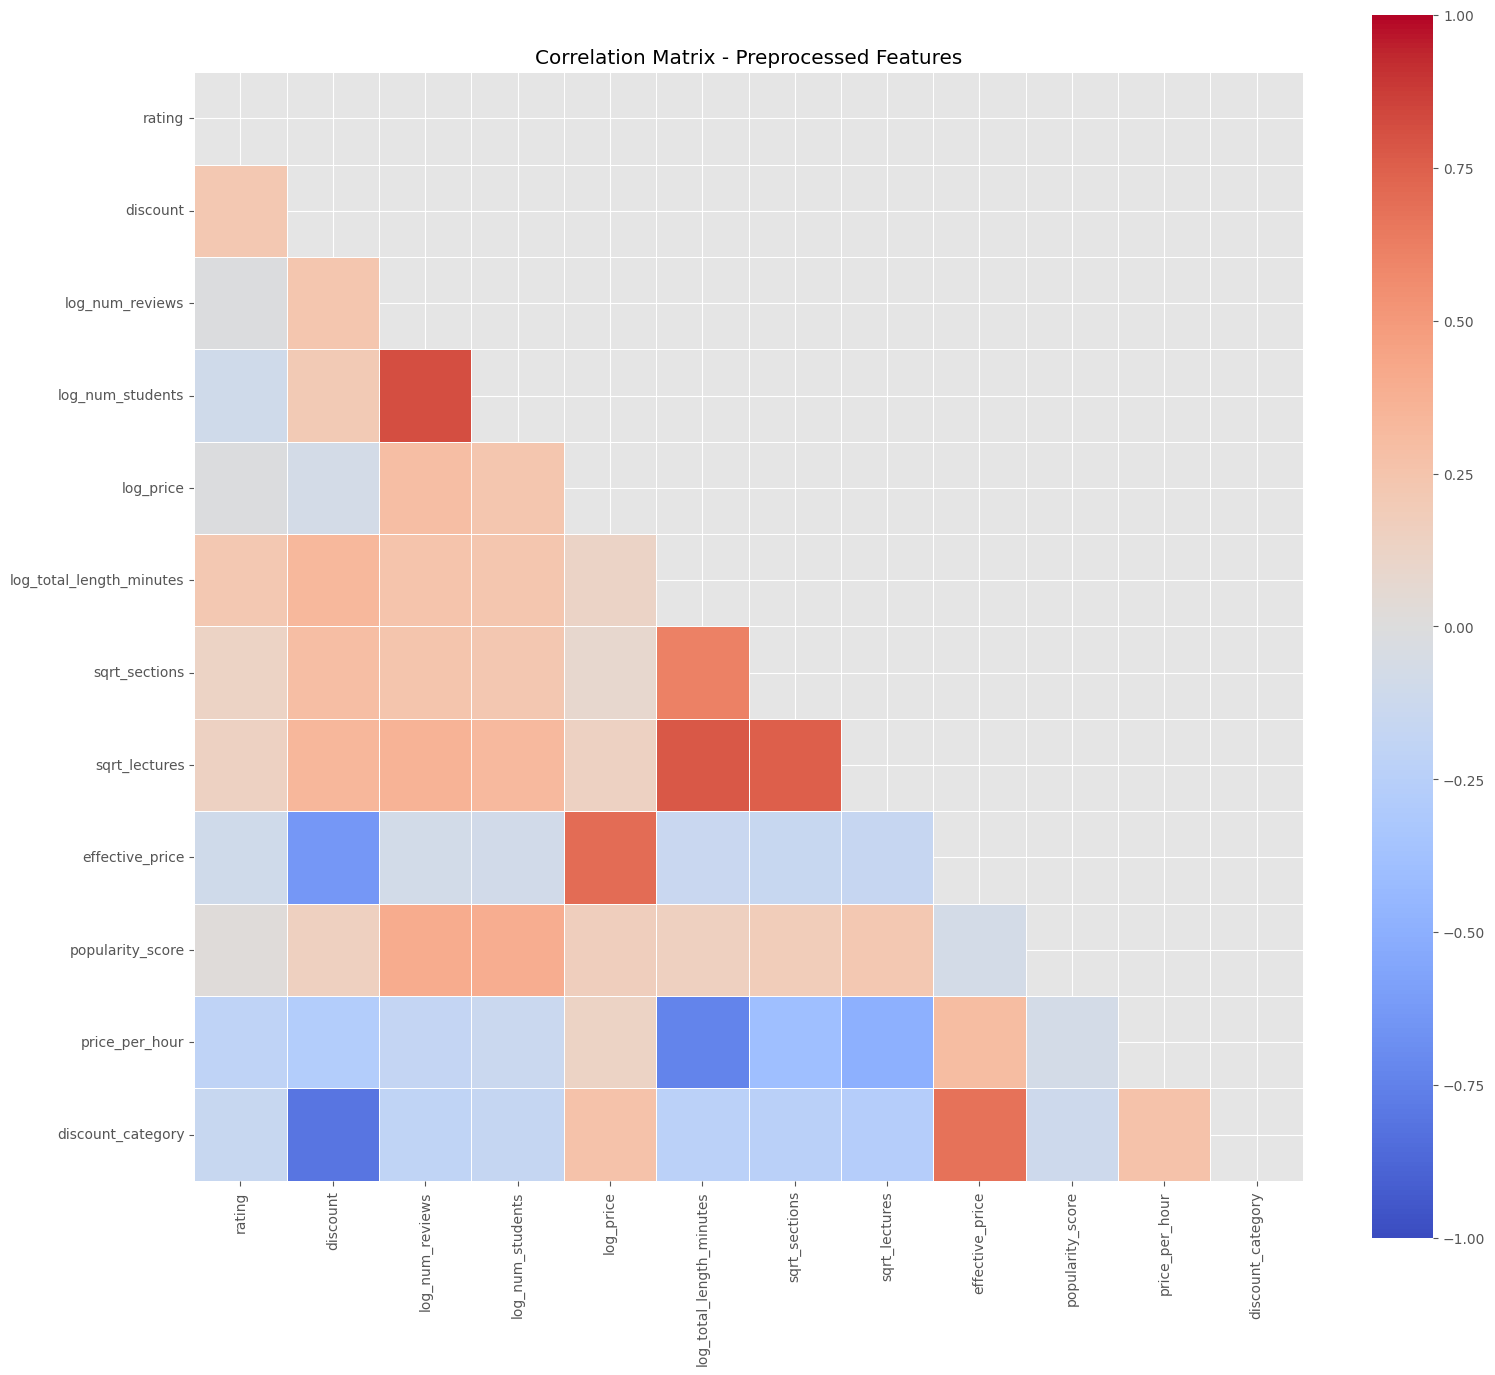

In [34]:
# Kiểm tra correlation matrix sau preprocessing
plt.figure(figsize=(16, 14))
corr = X_train_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Matrix - Preprocessed Features')
plt.tight_layout()
plt.show()


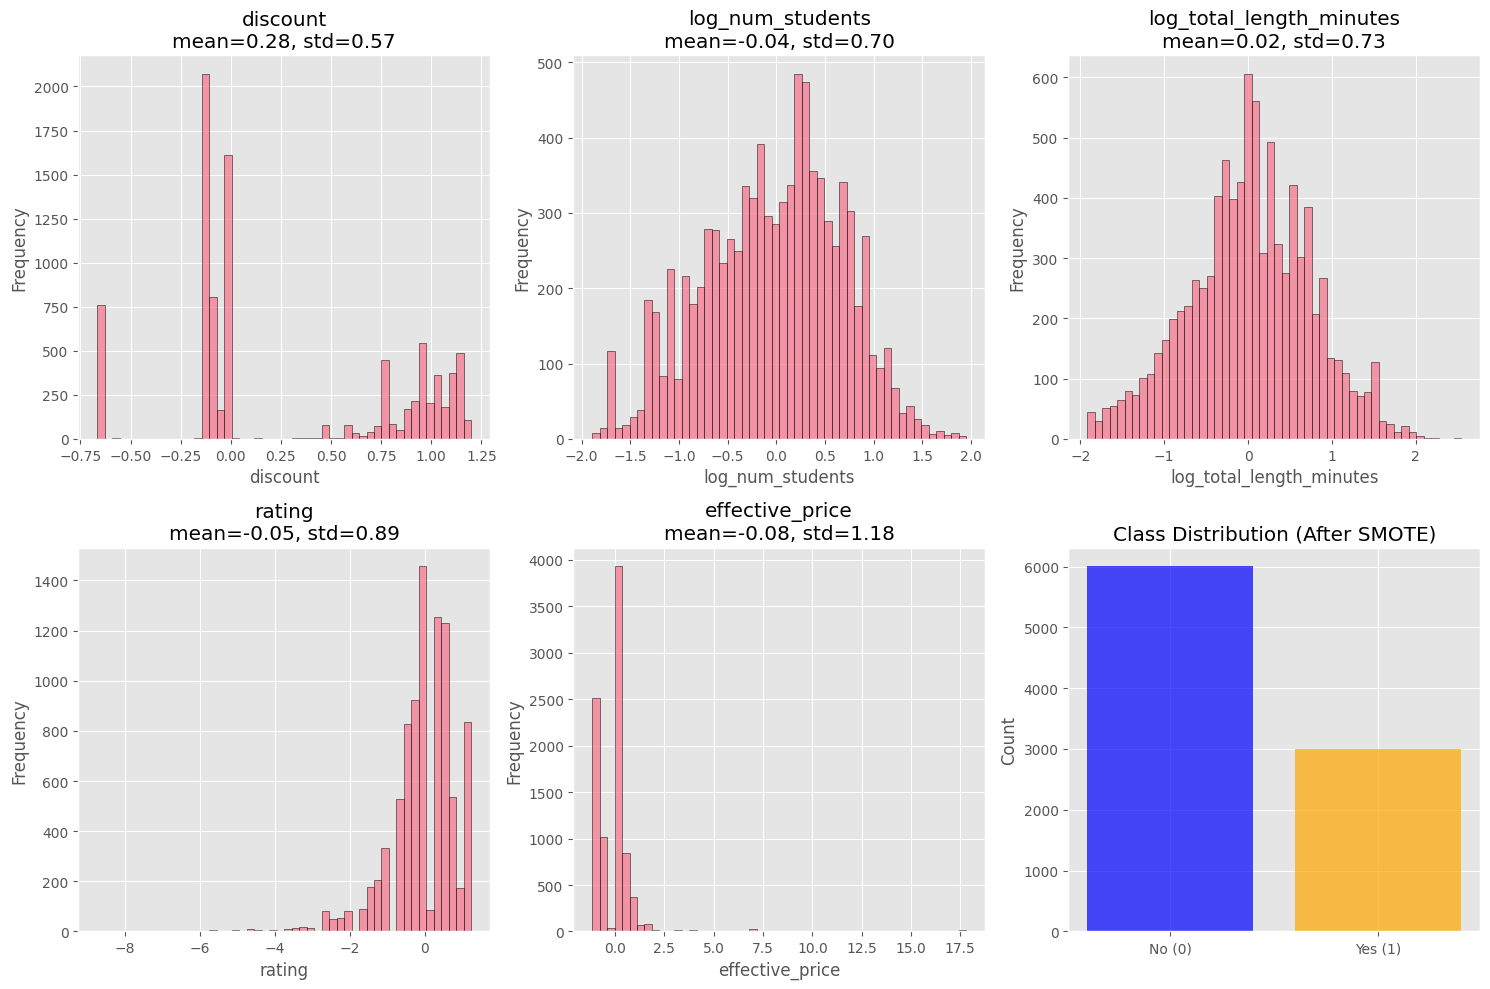

In [35]:
# Visualize phân phối một số features quan trọng sau preprocessing
important_features = ['discount', 'log_num_students', 'log_total_length_minutes', 
                      'rating', 'effective_price']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(important_features):
    if col in X_train_df.columns:
        axes[i].hist(X_train_df[col], bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col}\nmean={X_train_df[col].mean():.2f}, std={X_train_df[col].std():.2f}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

# Class distribution plot
axes[5].bar(['No (0)', 'Yes (1)'], 
            [(y_train_resampled==0).sum(), (y_train_resampled==1).sum()],
            color=['blue', 'orange'], alpha=0.7)
axes[5].set_title('Class Distribution (After SMOTE)')
axes[5].set_ylabel('Count')

plt.tight_layout()
plt.show()


In [36]:
df.head()


,timestamp,course_url,title,headline,is_bestseller,rating,num_students,instructor,language,price,discount,related_topics,lectures,total_length_minutes,log_num_reviews,log_num_students,price_capped,log_price,log_total_length_minutes,sqrt_sections,sqrt_lectures,effective_price,popularity_score,rating_x_students,price_per_hour,discount_category
0,2025-10-06 19:36:49,https://www.udemy.com/course/machinelearning/,"Machine Learning A-Z: AI, Python & R + ChatGPT...",Learn to create Machine Learning Algorithms in...,Yes,4.5,1159767.0,Kirill,English,369000.0,0.81,"Machine Learning, Data Science, Development",386.0,2564,12.206478,13.963731,369000.0,12.818555,7.849714,6.782330,19.646883,70110.0,679923.5,5218951.5,8634.743337,High
1,2025-10-06 19:37:05,https://www.udemy.com/course/complete-machine-...,"Complete Data Science,Machine Learning,DL,NLP ...","Master the theory, practice,and math behind Da...",Yes,4.5,107821.0,Krish,English,349000.0,0.78,"Data Science, Other IT & Software, IT & Software",429.0,5950,7.901377,11.588237,349000.0,12.762830,8.691315,7.937254,20.712315,76780.0,55260.5,485194.5,3519.292242,High
2,2025-10-06 19:37:19,https://www.udemy.com/course/complete-machine-...,"Complete A.I. & Machine Learning, Data Science...","Learn Data Science, Data Analysis, Machine Lea...",No,4.6,153392.0,Andrei,English,339000.0,0.82,"Data Science, Development",384.0,2640,10.263293,11.940759,339000.0,12.733758,7.878913,4.582576,19.595918,61020.0,91026.0,705603.2,7704.370355,High
3,2025-10-06 19:38:12,https://www.udemy.com/course/machine-learning-...,Mathematical Foundations of Machine Learning,Essential Linear Algebra and Calculus Hands-On...,Yes,4.6,137461.0,Dr,English,389000.0,0.82,"Math, Data Science, Development",114.0,985,8.964056,11.831103,389000.0,12.871337,6.893656,3.316625,10.677078,70020.0,72638.5,632320.6,23693.988183,High
4,2025-10-06 19:38:54,https://www.udemy.com/course/machine-learning-...,Machine Learning for Absolute Beginners - Level 1,Learn the Fundamental Concepts of Artificial I...,No,4.5,115825.0,Idan,English,339000.0,0.24,"Machine Learning, Data Science, Development",59.0,267,10.277531,11.659844,339000.0,12.733758,5.590987,2.828427,7.681146,257640.0,72448.0,521212.5,76162.660076,Low


In [37]:
missing_data=pd.DataFrame(
    {
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percent' : ((df.isnull().sum()/len(df))*100).round(2),
        'Data_Type': df.dtypes
    }
)

missing_data=missing_data[missing_data['Missing_Count']>0].sort_values(by='Missing_Percent', ascending=False)

if len(missing_data)>0:
    print("\n📊 Missing Value Summary:")
    print(missing_data.to_string(index=False))


📊 Missing Value Summary:
           Column  Missing_Count  Missing_Percent Data_Type
discount_category            308             3.16  category


## 14. Save Preprocessed Data


In [38]:
# Luu du lieu da preprocessing (scaled + SMOTE cho train, chi scaled cho test)
X_train_final = pd.DataFrame(X_train_resampled, columns=X_train_scaled.columns)
X_test_final = pd.DataFrame(X_test_scaled.values, columns=X_test_scaled.columns)
y_train_final = pd.Series(y_train_resampled, name='is_bestseller')
y_test_final = pd.Series(y_test.values, name='is_bestseller')

X_train_final.to_csv('X_train.csv', index=False)
X_test_final.to_csv('X_test.csv', index=False)
y_train_final.to_csv('y_train.csv', index=False)
y_test_final.to_csv('y_test.csv', index=False)

import joblib
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [39]:
# Import thư viện cho Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Import thư viện cho đánh giá
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)

# Import thư viện khác
import time
import joblib

print("Đã import tất cả thư viện cần thiết cho modeling!")


Đã import tất cả thư viện cần thiết cho modeling!


In [40]:
# Khởi tạo dictionary chứa các models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, n_estimators=100, verbose=-1),
    'AdaBoost': AdaBoostClassifier(random_state=42, n_estimators=100),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(random_state=42, probability=True)
}

print(f"Đã khởi tạo {len(models)} models:")
for i, name in enumerate(models.keys(), 1):
    print(f"  {i}. {name}")


Đã khởi tạo 10 models:
  1. Logistic Regression
  2. Decision Tree
  3. Random Forest
  4. Gradient Boosting
  5. XGBoost
  6. LightGBM
  7. AdaBoost
  8. K-Nearest Neighbors
  9. Naive Bayes
  10. Support Vector Machine


In [41]:
# Load dữ liệu từ các file đã lưu
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv')['is_bestseller'].values
y_test = pd.read_csv('y_test.csv')['is_bestseller'].values

In [42]:
# Dictionary để lưu kết quả
results = {}
trained_models = {}

print("=" * 80)
print("BẮT ĐẦU TRAINING VÀ ĐÁNH GIÁ MODELS")
print("=" * 80)

# Train và đánh giá từng model
for name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Training: {name}")
    print(f"{'='*80}")
    
    # Bắt đầu đo thời gian
    start_time = time.time()
    
    try:
        # Train model
        model.fit(X_train, y_train)
        
        # Dự đoán
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Tính thời gian training
        train_time = time.time() - start_time
        
        # Tính các metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        # Lưu kết quả
        results[name] = {
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'ROC-AUC': roc_auc,
            'Training Time': train_time,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }
        
        # Lưu trained model
        trained_models[name] = model
        
        # In kết quả
        print(f"\nKết quả:")
        print(f"  Accuracy:      {accuracy:.4f}")
        print(f"  Precision:     {precision:.4f}")
        print(f"  Recall:        {recall:.4f}")
        print(f"  F1-Score:      {f1:.4f}")
        print(f"  ROC-AUC:       {roc_auc:.4f}")
        print(f"  Training Time: {train_time:.2f}s")
        
    except Exception as e:
        print(f"  LỖI: {str(e)}")
        continue

print(f"\n{'='*80}")
print("ĐÃ HOÀN THÀNH TRAINING TẤT CẢ MODELS!")
print(f"{'='*80}")


BẮT ĐẦU TRAINING VÀ ĐÁNH GIÁ MODELS

Training: Logistic Regression

Kết quả:
  Accuracy:      0.8028
  Precision:     0.5651
  Recall:        0.6267
  F1-Score:      0.5943
  ROC-AUC:       0.8416
  Training Time: 0.03s

Training: Decision Tree

Kết quả:
  Accuracy:      0.8827
  Precision:     0.7429
  Recall:        0.7511
  F1-Score:      0.7470
  ROC-AUC:       0.8944
  Training Time: 0.05s

Training: Random Forest

Kết quả:
  Accuracy:      0.9175
  Precision:     0.8773
  Recall:        0.7467
  F1-Score:      0.8067
  ROC-AUC:       0.9491
  Training Time: 1.20s

Training: Gradient Boosting

Kết quả:
  Accuracy:      0.8827
  Precision:     0.7576
  Recall:        0.7222
  F1-Score:      0.7395
  ROC-AUC:       0.9280
  Training Time: 1.83s

Training: XGBoost

Kết quả:
  Accuracy:      0.9083
  Precision:     0.8346
  Recall:        0.7511
  F1-Score:      0.7906
  ROC-AUC:       0.9423
  Training Time: 0.13s

Training: LightGBM

Kết quả:
  Accuracy:      0.9103
  Precision:    

In [43]:
# Tạo DataFrame để so sánh kết quả
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['Accuracy'] for m in results.keys()],
    'Precision': [results[m]['Precision'] for m in results.keys()],
    'Recall': [results[m]['Recall'] for m in results.keys()],
    'F1-Score': [results[m]['F1-Score'] for m in results.keys()],
    'ROC-AUC': [results[m]['ROC-AUC'] for m in results.keys()],
    'Training Time (s)': [results[m]['Training Time'] for m in results.keys()]
})

# Sắp xếp theo F1-Score giảm dần
comparison_df = comparison_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\nBẢNG SO SÁNH CÁC MODELS (sắp xếp theo F1-Score):")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Tìm model tốt nhất
best_model_name = comparison_df.iloc[0]['Model']
print(f"\nMODEL TỐT NHẤT: {best_model_name}")
print(f"F1-Score: {comparison_df.iloc[0]['F1-Score']:.4f}")



BẢNG SO SÁNH CÁC MODELS (sắp xếp theo F1-Score):
                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  Training Time (s)
         Random Forest  0.917520   0.877285 0.746667  0.806723 0.949098           1.200233
              LightGBM  0.910348   0.834550 0.762222  0.796748 0.943607           3.013189
               XGBoost  0.908299   0.834568 0.751111  0.790643 0.942265           0.127182
         Decision Tree  0.882684   0.742857 0.751111  0.746961 0.894398           0.049028
     Gradient Boosting  0.882684   0.757576 0.722222  0.739477 0.927993           1.828378
   K-Nearest Neighbors  0.874488   0.725275 0.733333  0.729282 0.896018           0.099560
              AdaBoost  0.844262   0.655319 0.684444  0.669565 0.886854           0.766094
Support Vector Machine  0.833504   0.623274 0.702222  0.660397 0.864831           9.703123
   Logistic Regression  0.802766   0.565130 0.626667  0.594310 0.841626           0.032844
           Naive Bayes  0.755635   0.476